# Classifying Penguins with Keras Day 2

In [1]:
!pip install optuna


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

c:\Users\prchandr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
# drop Nan rows
penguins.dropna(inplace=True)

In [5]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [6]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [7]:
#construct the model
tf.random.set_seed(42) # set the seed before defining the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(16, activation = 'relu')(inputs)
x = layers.Dense(8, activation = 'relu')(x)
x = layers.Dense(4, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [8]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299 (1.17 KB)

 Trainable params: 299 (1.17 KB)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [9]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=50, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step - accuracy: 0.3679 - loss: 1.2796 - val_accuracy: 0.3889 - val_loss: 1.2773
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3726 - loss: 1.2490 - val_accuracy: 0.3889 - val_loss: 1.2467
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3821 - loss: 1.2202 - val_accuracy: 0.4074 - val_loss: 1.2177
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4057 - loss: 1.1930 - val_accuracy: 0.4444 - val_loss: 1.1900
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4104 - loss: 1.1673 - val_accuracy: 0.4630 - val_loss: 1.1635
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4151 - loss: 1.1432 - val_accuracy: 0.4444 - val_loss: 1.1386
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4387 - loss: 1.1207 - val_accuracy: 0.4444 - val_loss: 1.1152
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4623 - loss: 1.0997 - val_accuracy: 0.4444 - val_loss: 1.0

### Evaluating on the test data

In [10]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

 Test Set Evaluation:
Test Accuracy: 0.9104
Test Precision: 0.9102
Test Recall: 0.9104
Test F1 Score: 0.9072
Test ROC AUC Score: 0.9927


### Evaluating model training using loss and accuracy

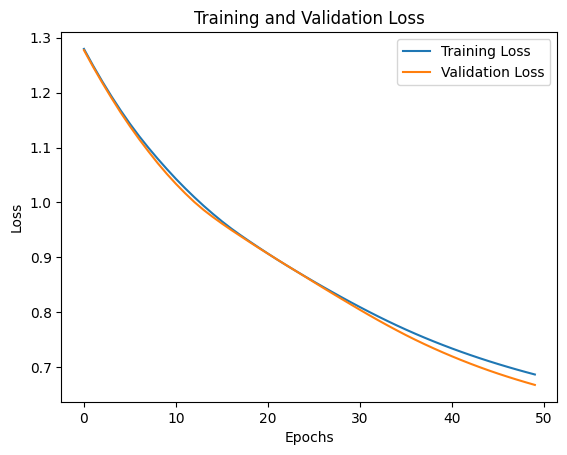

In [11]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

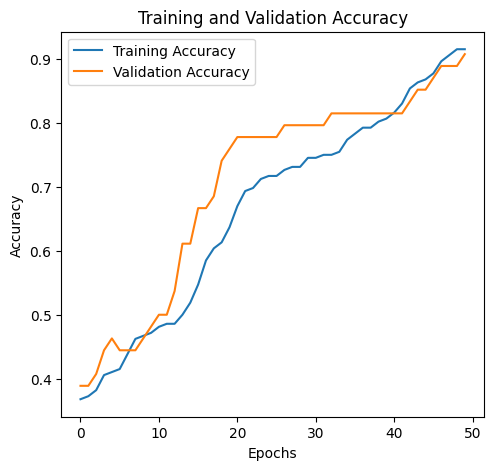

In [12]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

Every time I run the model, it varies in performance. When I first ran the model 3 times it went from 0.38, to 0.58, and then to 0.56. However when I set a random seed it varied more. This first time I got 0.35, second time 0.50, and 0.77 final score. I think this is happening because the starting weight matters a lot for the rest of model. When running the model the first time, the model memorizes its score weighting and re-assigns it again after for the second time, etc.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

When I set random seed = 42, I saw much more consistent and clear curves within the training and validation curves with less variation.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

1. I changed the number of layers from 2 to 3 and I used 16, 8, 4 which improved my baseline model from the previous 7 to 5 neurons per layer. I noticed that my loss was higher (0.9) than my accuracy (0.59) which was substanially different then the model when it was 7 to 5. It is a bit worrisome that my loss was so high and I wanted to use a flat strategy next to see how the model would perform without changing the number of neurons per layer. As for the training and validation curve it stayed pretty consistent and stable at around 0.40 accuracy until it reached 5-6 epochs which pushed it to 0.55 accuracy.  I restarted the kernal to see what it would perform at the start and recieved accuracy: 0.4478 - loss: 1.1359 which is good for baseline model.
2. I changed the architecture to 8, 8, 8 and the loss was higher than before at 1.14 at the start and accuracy was at able 0.56 similar to before. The training and validation curves were very similar with an postive slope line. The highest point of accuracy was at 0.65. This indicates to me that the model is performing better because it the training/validation lines are similar. When i restarted the kernal I recieved accuracy: 0.3582 - loss: 1.1008.
3. I tried using 16,16,16 neurons per layer and I received accuracy of 0.4627 and loss 0.9840 probably because it is overkill on the penguins dataset. The training and validation curves stayed the same as architecture #2 and both lines tended to overlap with one another.
4. Finally I tried using 4, 8, 16. I did not think this would improve the model more than 16, 8, 4 and it performed similar to the other neurons i tried because i received accuracy: 0.4328 and loss: 0.9729. The training curve had higher accuracy than validation curve but after around 4.5 epochs validation accuracy started to be better than the training accuracy. 
From all the architectures I tried, the layers with nuerons 16, 16, 16 performed the best with the highest accuracy but only by a little bit.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

1. I changed the number of epochs to 50 and recieved a validation accuracy of 0.8 and loss of 0.7. I noticed that after about 12 epochs the validation score ended up stabilizing and the other epochs did not change it too much.
2. Afterwards I tried 5 epochs to see how the model performs and I got validation accuracy of 0.60 and loss of 1.10 so it clear the number of epochs truly did make a massive change in model performance.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [13]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.3726 - loss: 1.2571 - val_accuracy: 0.3704 - val_loss: 1.2312
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3585 - loss: 1.2488 - val_accuracy: 0.3704 - val_loss: 1.2234
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3585 - loss: 1.2390 - val_accuracy: 0.3704 - val_loss: 1.2161
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3774 - loss: 1.2327 - val_accuracy: 0.3704 - val_loss: 1.2083
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3585 - loss: 1.2343 - val_accuracy: 0.4074 - val_loss: 1.2008
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3632 - loss: 1.2220 - val_accuracy: 0.4259 - val_loss: 1.1934
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3632 - loss: 1.2172 - val_accuracy: 0.4259 - val_loss: 1.1862
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4009 - loss: 1.2150 - val_accuracy: 0.4444 - val_loss

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [15]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=15,  # max training epochs
        validation_split=0.25,  # validation portion of training data
        verbose=1,  # progress bars
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-15 22:41:22,707] A new study created in memory with name: no-name-b31131d1-83df-4944-bcc0-37abe7ce8243


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.1256 - loss: 1.6319 - val_accuracy: 0.1791 - val_loss: 1.6193
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1307 - loss: 1.6231 - val_accuracy: 0.1940 - val_loss: 1.6108
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1407 - loss: 1.6144 - val_accuracy: 0.2090 - val_loss: 1.6025
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1457 - loss: 1.6058 - val_accuracy: 0.2090 - val_loss: 1.5943
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1457 - loss: 1.5973 - val_accuracy: 0.2239 - val_loss: 1.5861
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1558 - loss: 1.5888 - val_accuracy: 0.2239 - val_loss: 1.5779
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1608 - loss: 1.5805 - val_accuracy: 0.2239 - val_loss: 1.5698
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1759 - loss: 1.5722 - val_accuracy: 0.2239 - val_loss: 1.5618


[I 2026-05-15 22:41:33,425] Trial 0 finished with value: 1.507447600364685 and parameters: {'num_layers': 1, 'learning_rate': 0.00018205761729362538, 'batch_size': 32, 'num_units_layer_1': 7}. Best is trial 0 with value: 1.507447600364685.


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6884 - loss: 0.8307 - val_accuracy: 0.8060 - val_loss: 0.5299
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8643 - loss: 0.3840 - val_accuracy: 0.9254 - val_loss: 0.2347
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9698 - loss: 0.1513 - val_accuracy: 0.9701 - val_loss: 0.1046
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9899 - loss: 0.0517 - val_accuracy: 0.9851 - val_loss: 0.0618
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9950 - loss: 0.0258 - val_accuracy: 0.9851 - val_loss: 0.0415
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 0.9851 - val_loss: 0.0393
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.9851 - val_loss: 0.0378
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9851 - v

[I 2026-05-15 22:41:39,996] Trial 1 finished with value: 0.03778975456953049 and parameters: {'num_layers': 3, 'learning_rate': 0.004987694402992972, 'batch_size': 16, 'num_units_layer_1': 23, 'num_units_layer_2': 20, 'num_units_layer_3': 27}. Best is trial 1 with value: 0.03778975456953049.


...

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.3869 - loss: 1.0904 - val_accuracy: 0.3731 - val_loss: 1.1222
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4271 - loss: 1.0695 - val_accuracy: 0.3731 - val_loss: 1.1023
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4472 - loss: 1.0503 - val_accuracy: 0.4030 - val_loss: 1.0831
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4774 - loss: 1.0321 - val_accuracy: 0.4030 - val_loss: 1.0650
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4824 - loss: 1.0147 - val_accuracy: 0.4179 - val_loss: 1.0479
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4975 - loss: 0.9981 - val_accuracy: 0.4328 - val_loss: 1.0310
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5176 - loss: 0.9820 - val_accuracy: 0.4627 - val_loss: 1.0144
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5477 - loss: 0.9663 - val_accuracy: 0.5373 - val_loss: 0.9984

[I 2026-05-15 22:42:18,487] Trial 6 finished with value: 0.8869510889053345 and parameters: {'num_layers': 2, 'learning_rate': 0.0004966047800735619, 'batch_size': 64, 'num_units_layer_1': 24, 'num_units_layer_2': 11}. Best is trial 1 with value: 0.03778975456953049.


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.2060 - loss: 1.2108 - val_accuracy: 0.1791 - val_loss: 1.2112
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2060 - loss: 1.1842 - val_accuracy: 0.1642 - val_loss: 1.1835
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2060 - loss: 1.1599 - val_accuracy: 0.1791 - val_loss: 1.1576
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2211 - loss: 1.1373 - val_accuracy: 0.2090 - val_loss: 1.1331
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2362 - loss: 1.1159 - val_accuracy: 0.2836 - val_loss: 1.1099
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3166 - loss: 1.0956 - val_accuracy: 0.3881 - val_loss: 1.0879
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4573 - loss: 1.0765 - val_accuracy: 0.5075 - val_loss: 1.0666
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5578 - loss: 1.0582 - val_accuracy: 0.5970 - val_loss: 1.0460

[W 2026-05-15 22:42:24,878] Trial 7 failed with parameters: {'num_layers': 3, 'learning_rate': 0.00047424565217762694, 'batch_size': 64, 'num_units_layer_1': 12, 'num_units_layer_2': 29, 'num_units_layer_3': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\prchandr\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\prchandr\AppData\Local\Temp\1\ipykernel_38148\1498327196.py", line 30, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "c:\Users\prchandr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\utils\traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\prchandr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\trainer.py", line 397,

KeyboardInterrupt: 

In [16]:
!pip install plotly



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [32, 16, 16, 16, 16, 32, 64],
              'xaxis': 'x',
              'y': [1.507447600364685, 0.03778975456953049, 0.09454596787691116,
                    0.37728509306907654, 0.6194737553596497, 1.475674033164978,
                    0.8869510889053345],
              'yaxis': 'y'},
             {'marker': {'color': [0, 1, 2, 3, 4, 5, 6],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.00018205761729362538, 0.004987694402992972,
                    0.0013270951430037464, 0.0007146085457950387,
                    0.0010490642497133086, 0.0002906760458162946,
                    0.0004966047800735619],
              'xaxis': 'x2',
              'y': [1.507447600364685, 0.03778975456953049, 0.09454596787691116,
                    0.37728509306907654, 0.6194737553596497, 1.475674033164978,
                    0.8869510889053345],
              'yaxis': 'y2'},
             {'marker': {'color': [0, 1, 2, 3, 4, 5, 6],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [1, 3, 2, 3, 2, 1, 2],
              'xaxis': 'x3',
              'y': [1.507447600364685, 0.03778975456953049, 0.09454596787691116,
                    0.37728509306907654, 0.6194737553596497, 1.475674033164978,
                    0.8869510889053345],
             

In [18]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6462 - loss: 0.8921 - val_accuracy: 0.8148 - val_loss: 0.5832
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8349 - loss: 0.4684 - val_accuracy: 0.9630 - val_loss: 0.2371
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9292 - loss: 0.1949 - val_accuracy: 0.9630 - val_loss: 0.1003
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9858 - loss: 0.0569 - val_accuracy: 0.9815 - val_loss: 0.0507
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9953 - loss: 0.0215 - val_accuracy: 0.9815 - val_loss: 0.0582
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.9815 - val_loss: 0.0523
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.9815 - val_loss: 0.0700
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.9815 - v